# Full LR Sweep: PT_LR × FT_LR × Burst Frac × FG_LR

Sweeps all learning rate knobs + burst fraction. Lite mode (no gradient metrics).

In [9]:
import sys, os, importlib
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")

import simple.model, simple.data, simple.pretrain, simple.finetune, simple.forget, simple.report
for name in ["simple.model", "simple.data", "simple.pretrain", "simple.finetune",
             "simple.forget", "simple.report"]:
    importlib.reload(sys.modules[name])

from simple import make_data, pretrain, report
from simple.finetune import _finetune_worker
from simple.forget import _forget_worker
import torch.multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
import pickle
%matplotlib inline

SEED = 42

In [10]:
# ── Sweep grid ──────────────────────────────────────────
LRS   = [5e-5, 1e-4, 3e-4, 1e-3]
FRACS = [1.0, 0.95, 0.9, 0.7, 0.5, 0.3]

FT_STEPS = 1500
FG_STEPS = 1000
PT_LRS = [1e-3, 1e-4]
FG_LRS = [1e-4, 1e-5]
BATCH_SIZE = 512
EVAL_EVERY = 50
OUT = f"data/lr_sweep_{BATCH_SIZE}_SWEEP"

n_ft_lr, n_frac = len(LRS), len(FRACS)
total = len(PT_LRS) * len(LRS) * len(FRACS) * len(FG_LRS)
print(f"Total: {len(PT_LRS)} PT_LRs × {n_ft_lr} FT_LRs × {n_frac} fracs × {len(FG_LRS)} FG_LRs = {total} runs")

Total: 2 PT_LRs × 4 FT_LRs × 6 fracs × 2 FG_LRs = 96 runs


In [11]:
data = make_data(depth=3, burst_pos=3, n_a=4, n_burst=4, seed=SEED)
print(f"Other tasks: {data['task_info']['n_other_tasks']}, Burst tasks: {data['task_info']['n_burst_tasks']}")

Other tasks: 64, Burst tasks: 64


In [12]:
# ── Run full sweep ──
ctx = mp.get_context("spawn")
n_workers = min(n_ft_lr * n_frac, 10)

all_results = {}  # keyed by (pt_lr, fg_lr)

for pt_lr in PT_LRS:
    # Pretrain once per PT_LR
    pt_dir = f"{OUT}/pretrain_lr{pt_lr:.0e}"
    print(f"\n{'='*60}")
    print(f"Pretraining with lr={pt_lr:.0e}...")
    pt = pretrain(data, pt_dir, seed=SEED, batch_size=BATCH_SIZE, lr=pt_lr)
    print(f"  Done. ckpt={pt['ckpt_path']}")

    # Finetune: sweep FT_LR × FRAC (parallel)
    ft_jobs = []
    for lr in LRS:
        for frac in FRACS:
            tag = f"pt{pt_lr:.0e}_ft{lr:.0e}_b{int(frac*100)}"
            ft_jobs.append(dict(data=data, pretrain_ckpt=pt["ckpt_path"],
                                out_dir=f"{OUT}/finetune",
                                burst_frac=frac, steps=FT_STEPS, lr=lr,
                                batch_size=BATCH_SIZE, eval_every=EVAL_EVERY,
                                tag=tag, seed=SEED, quiet=True, lite=True))

    print(f"  FT: {len(ft_jobs)} jobs, {n_workers} workers...")
    with ctx.Pool(n_workers) as pool:
        ft_results = pool.map(_finetune_worker, ft_jobs)

    # Forget: sweep FG_LR for each FT result (parallel)
    for fg_lr in FG_LRS:
        fg_jobs = [dict(data=data, finetune_ckpt=ft_r["ckpt_path"],
                        pretrain_ckpt=pt["ckpt_path"],
                        out_dir=f"{OUT}/forget",
                        steps=FG_STEPS, lr=fg_lr,
                        batch_size=BATCH_SIZE, eval_every=EVAL_EVERY,
                        tag=ft_r["tag"] + f"_fg{fg_lr:.0e}",
                        seed=SEED, quiet=True, lite=True)
                   for ft_r in ft_results]

        print(f"  FG (lr={fg_lr:.0e}): {len(fg_jobs)} jobs...")
        with ctx.Pool(n_workers) as pool:
            fg_results = pool.map(_forget_worker, fg_jobs)

        key = (pt_lr, fg_lr)
        all_results[key] = {"pt": pt, "ft_results": ft_results,
                            "fg_results": fg_results}
        print(f"  Stored results for PT_LR={pt_lr:.0e}, FG_LR={fg_lr:.0e}")

# Save everything
with open(f"{OUT}/sweep_results.pkl", "wb") as f:
    pickle.dump({"all_results": {str(k): v for k, v in all_results.items()},
                 "LRS": LRS, "FRACS": FRACS, "PT_LRS": PT_LRS, "FG_LRS": FG_LRS,
                 "FT_STEPS": FT_STEPS, "FG_STEPS": FG_STEPS}, f)
print(f"\nAll results saved to {OUT}/sweep_results.pkl")


Pretraining with lr=1e-03...


Pretrain: 0it [00:00, ?it/s]


Converged at step 750 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.6059
  Done. ckpt=data/lr_sweep_512_SWEEP/pretrain_lr1e-03/pretrain_ckpt.pt
  FT: 24 jobs, 10 workers...
  FG (lr=1e-04): 24 jobs...
  Stored results for PT_LR=1e-03, FG_LR=1e-04
  FG (lr=1e-05): 24 jobs...
  Stored results for PT_LR=1e-03, FG_LR=1e-05

Pretraining with lr=1e-04...


Pretrain: 0it [00:00, ?it/s]


Converged at step 1575 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.5881
  Done. ckpt=data/lr_sweep_512_SWEEP/pretrain_lr1e-04/pretrain_ckpt.pt
  FT: 24 jobs, 10 workers...
  FG (lr=1e-04): 24 jobs...
  Stored results for PT_LR=1e-04, FG_LR=1e-04
  FG (lr=1e-05): 24 jobs...
  Stored results for PT_LR=1e-04, FG_LR=1e-05

All results saved to data/lr_sweep_512_SWEEP/sweep_results.pkl


In [13]:
# ── Load saved results (uncomment to skip training) ──
# with open(f"{OUT}/sweep_results.pkl", "rb") as f:
#     saved = pickle.load(f)
# all_results = {eval(k): v for k, v in saved["all_results"].items()}
# LRS, FRACS = saved["LRS"], saved["FRACS"]
# PT_LRS, FG_LRS = saved["PT_LRS"], saved["FG_LRS"]
# n_ft_lr, n_frac = len(LRS), len(FRACS)
# print(f"Loaded {len(all_results)} (PT_LR, FG_LR) combos")

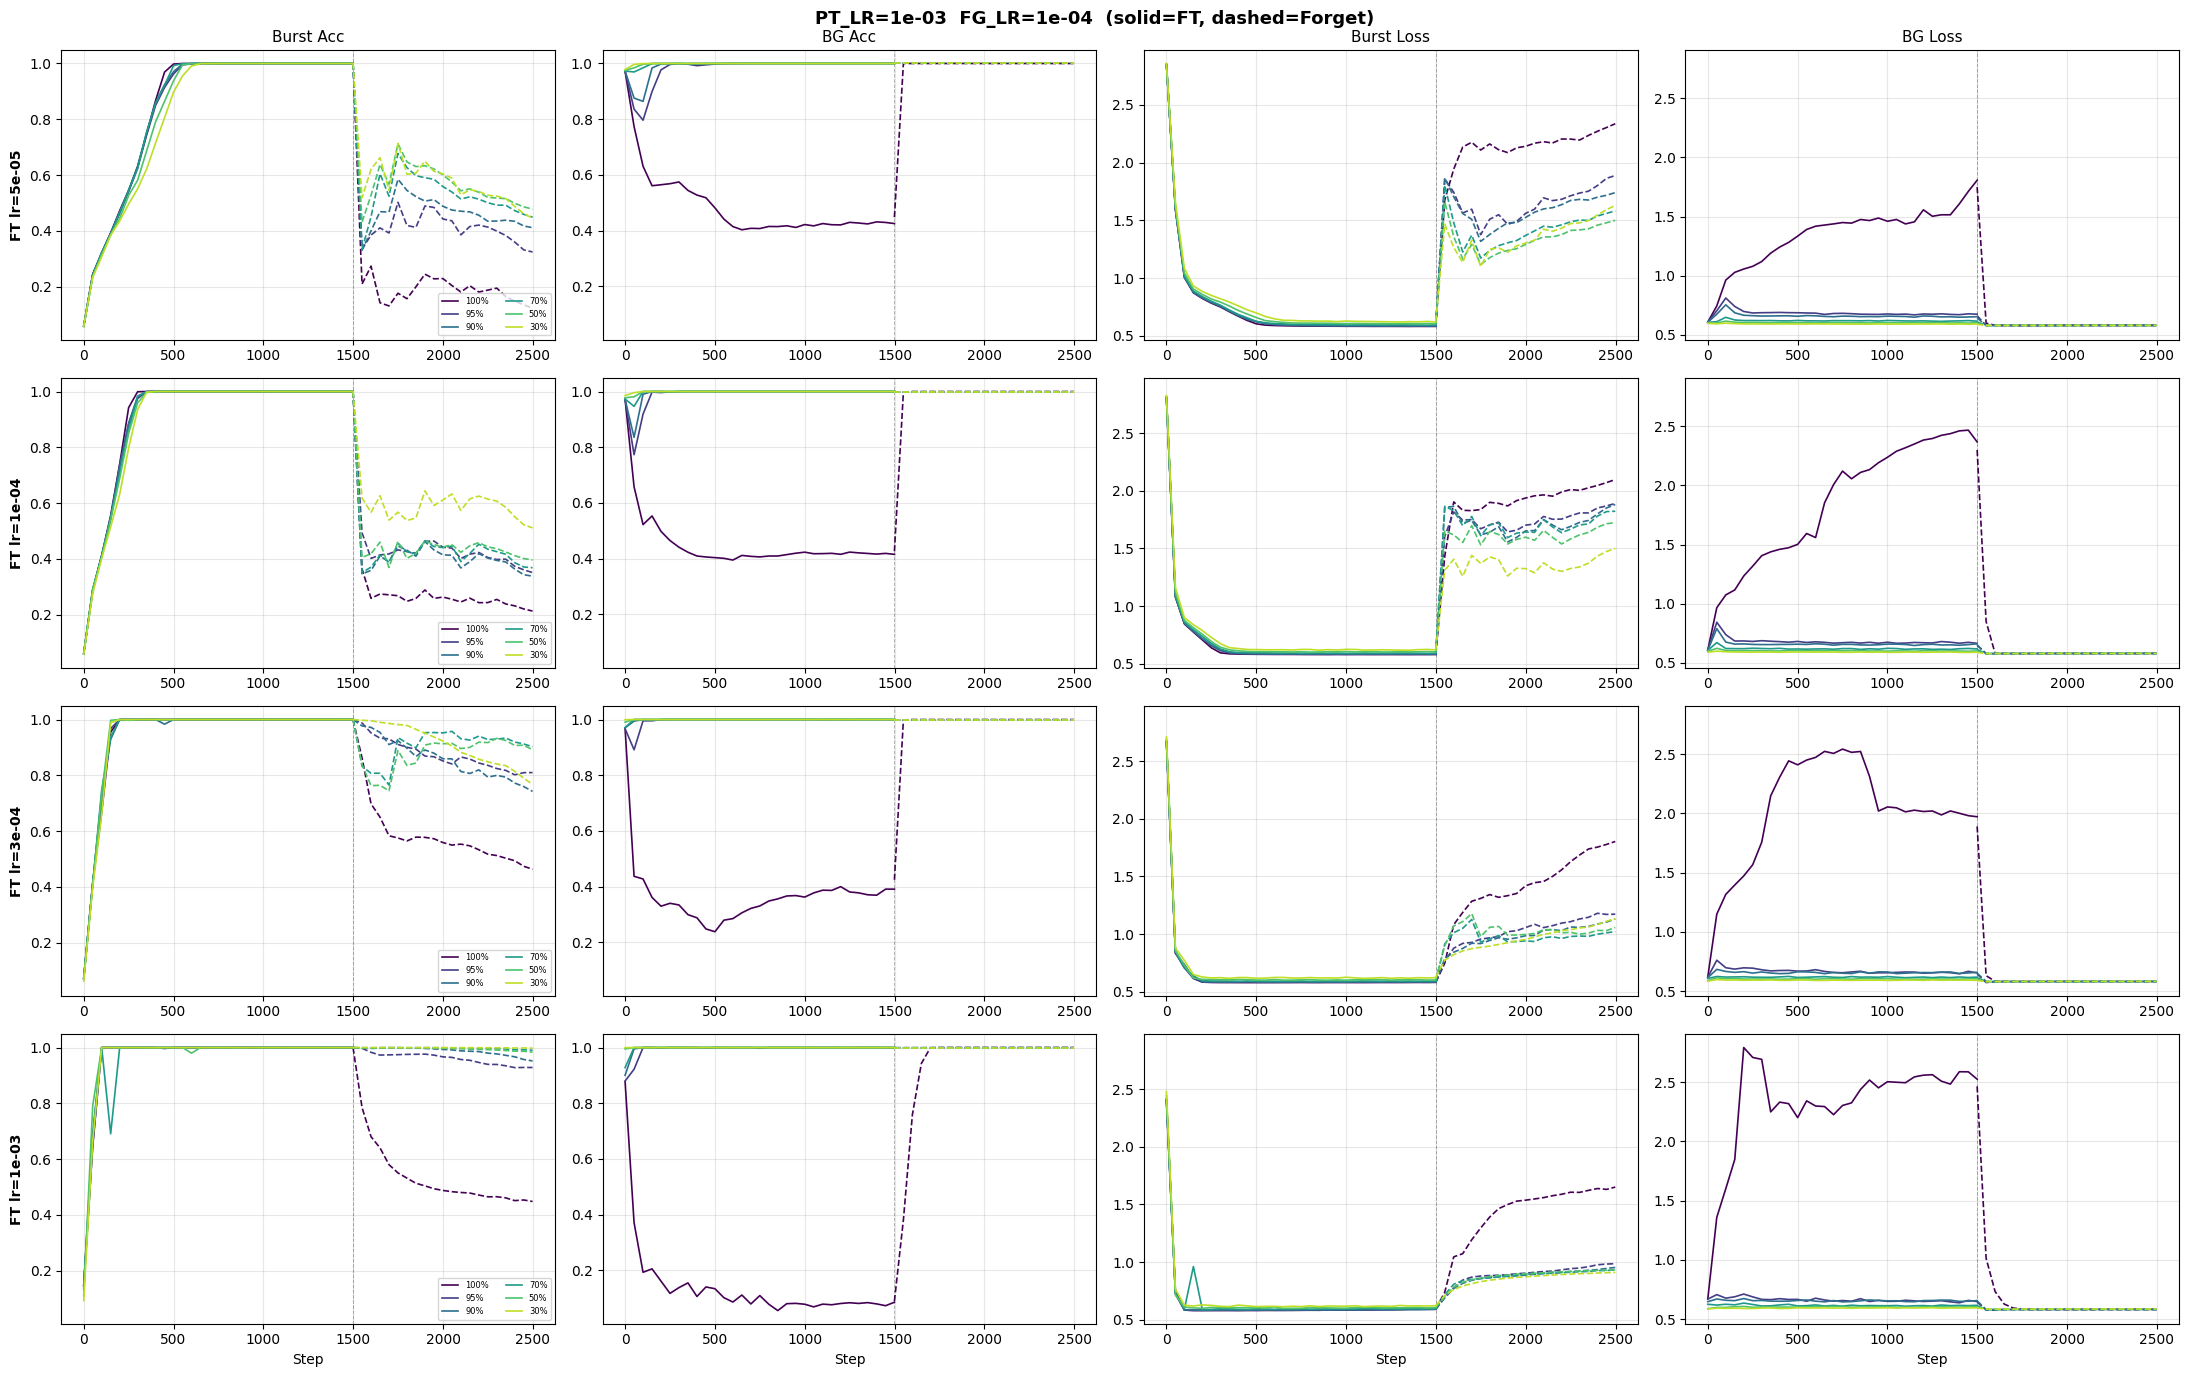

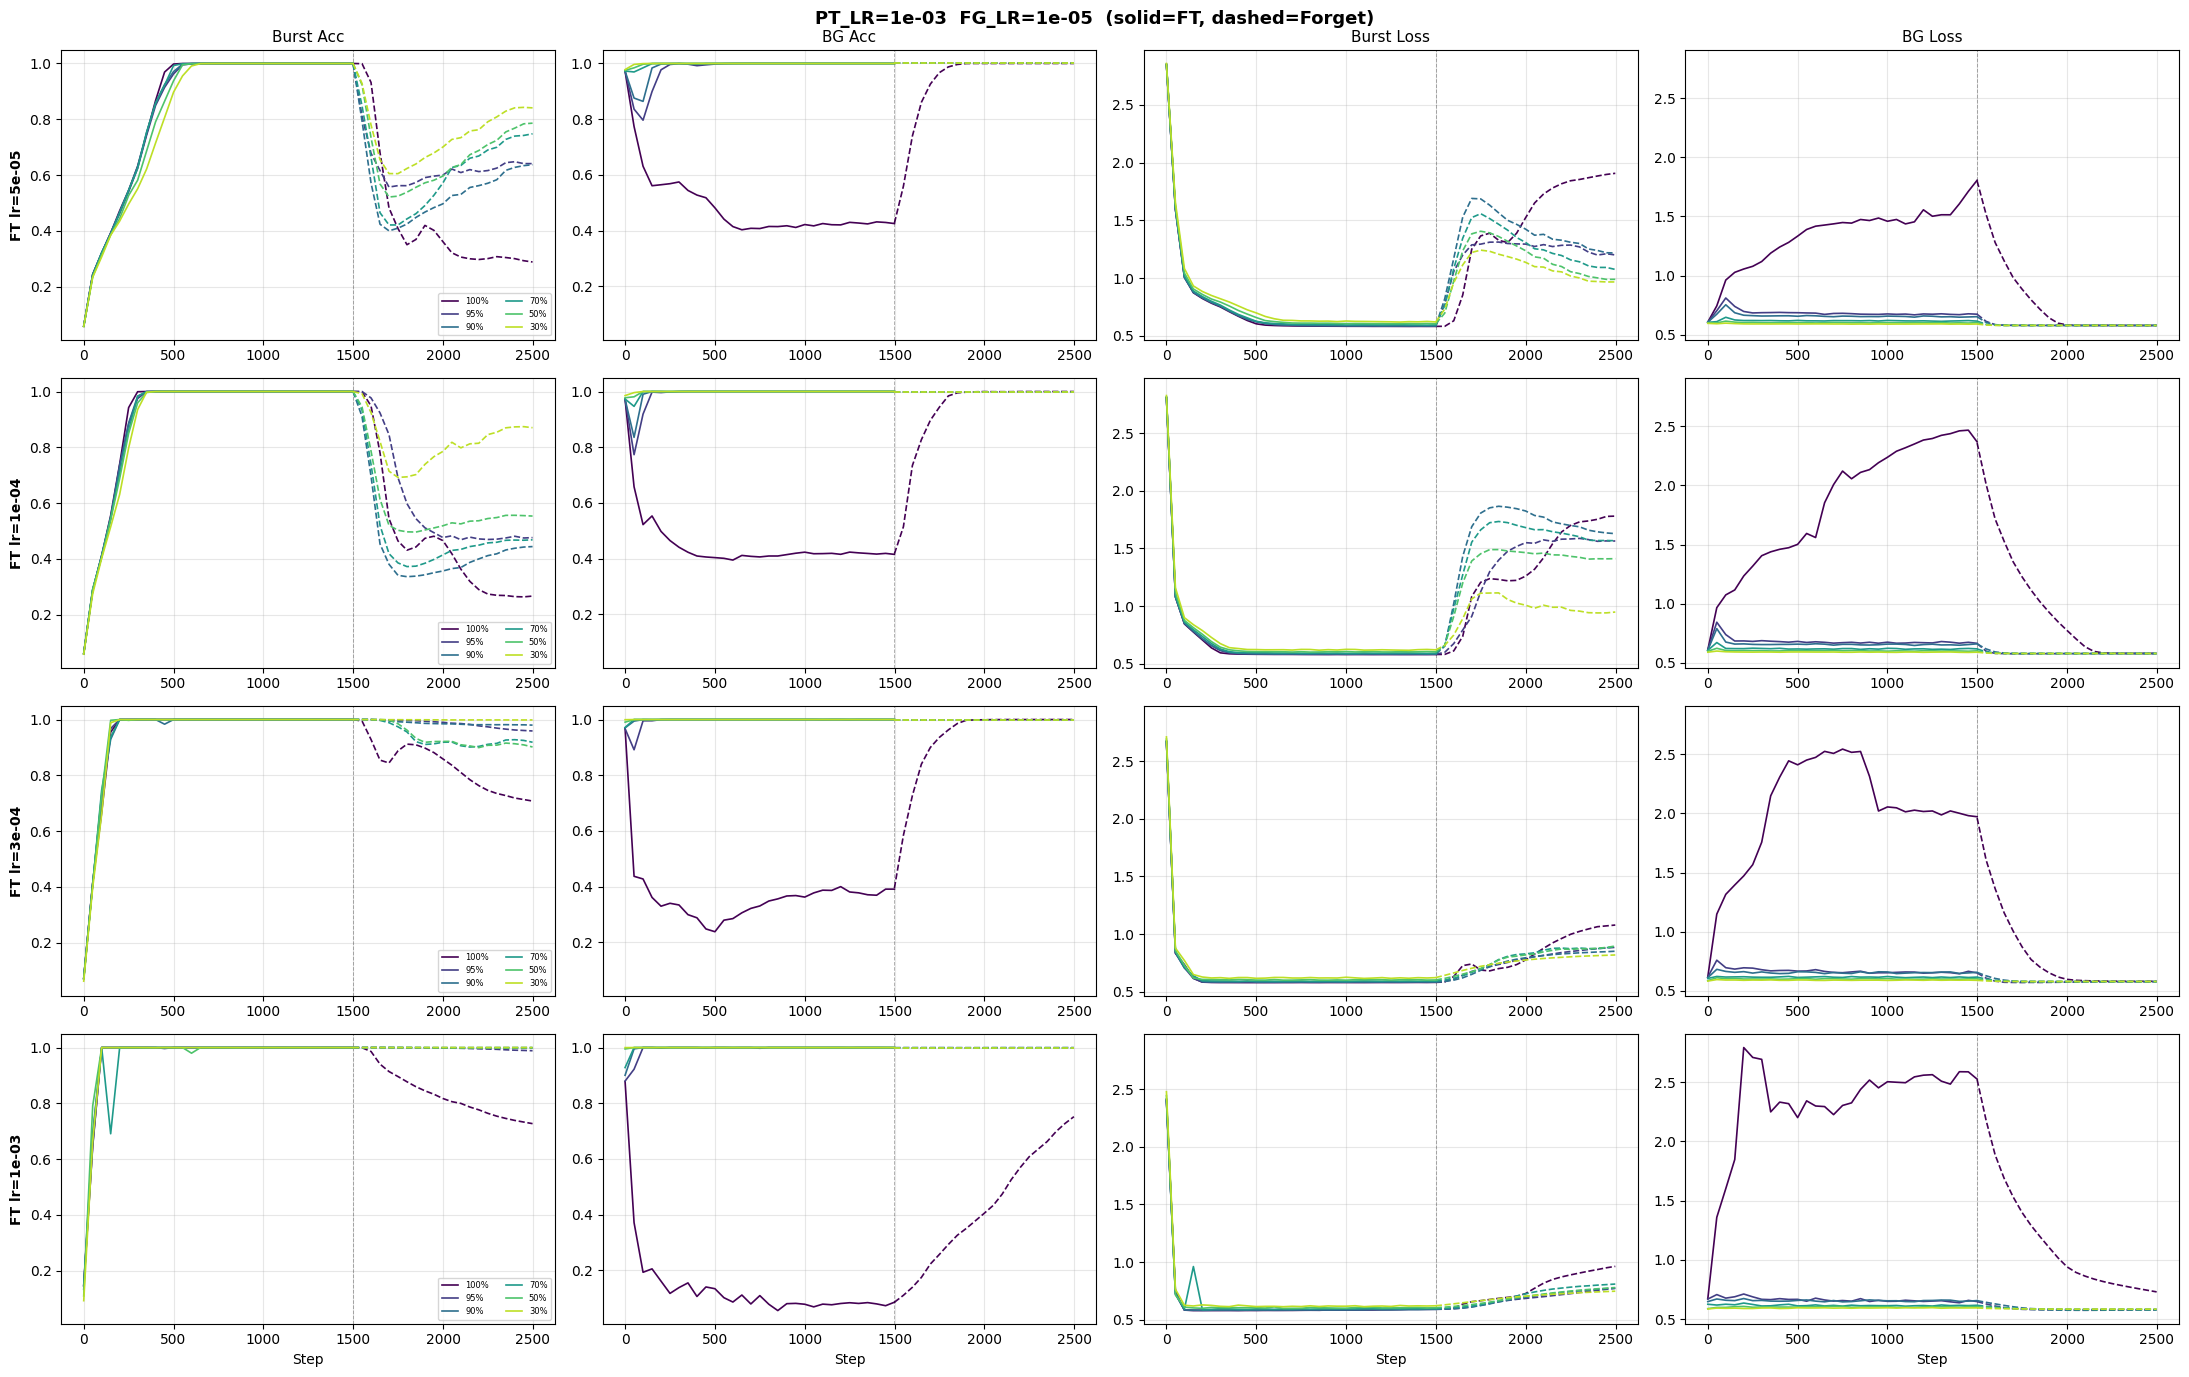

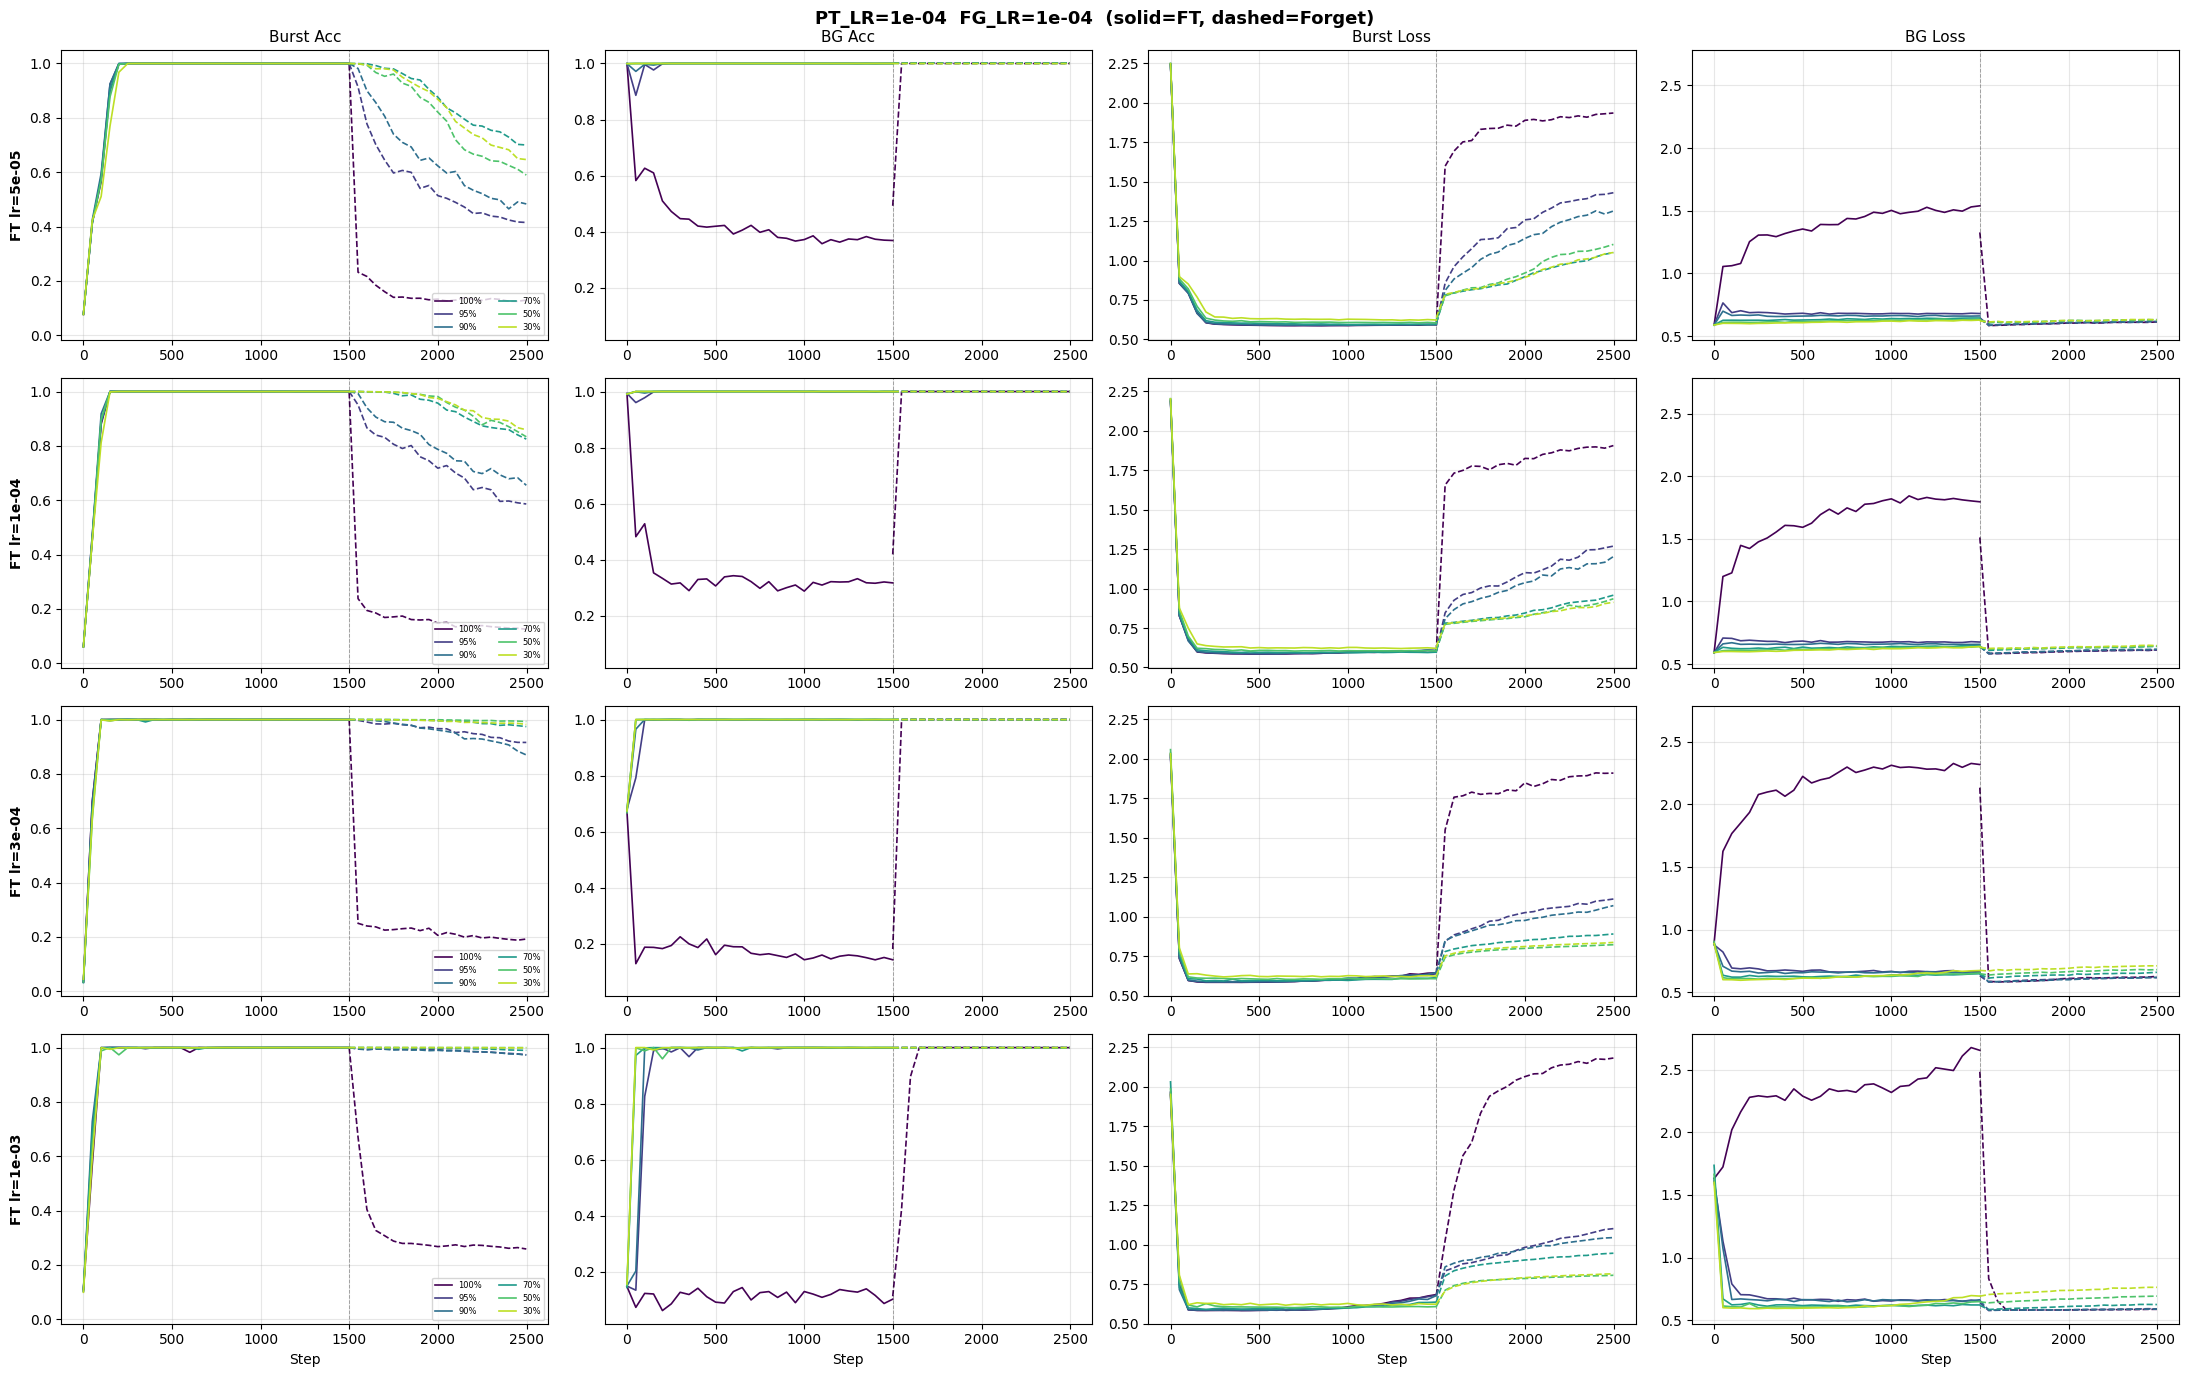

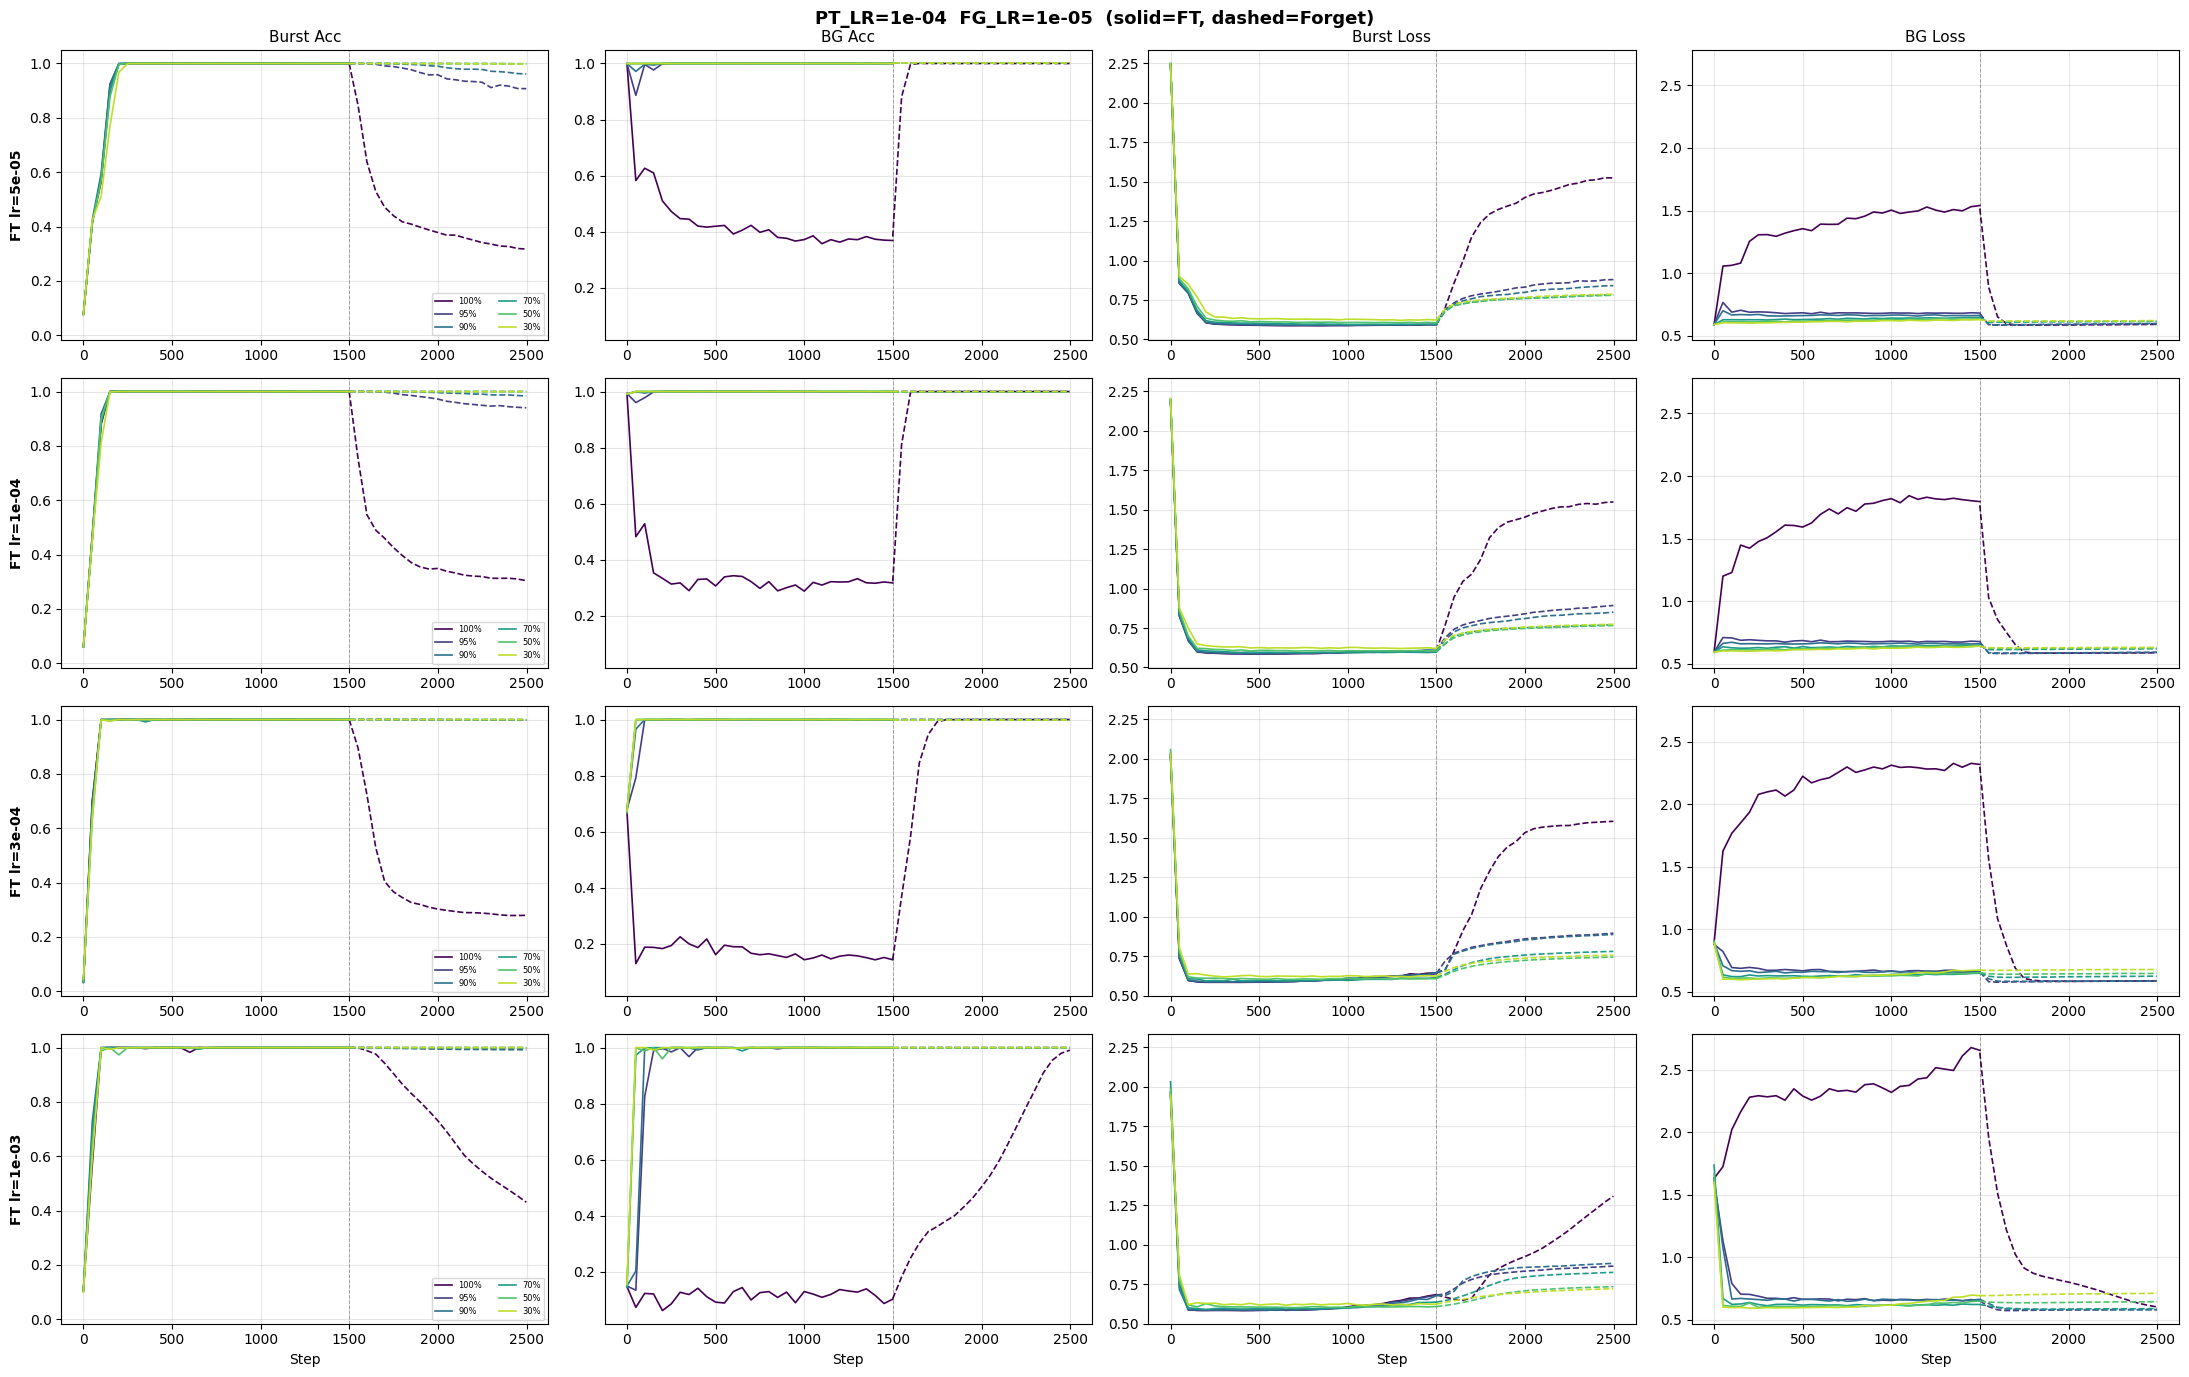

In [14]:
# ── Training curves: one figure per (PT_LR, FG_LR), rows=FT_LR, cols=metric ──
frac_colors = plt.cm.viridis(np.linspace(0, 0.9, n_frac))

for (pt_lr, fg_lr), res in all_results.items():
    ft_results = res["ft_results"]
    fg_results = res["fg_results"]

    fig, axes = plt.subplots(n_ft_lr, 4, figsize=(22, 3.5 * n_ft_lr), sharey='col')
    if n_ft_lr == 1:
        axes = axes[np.newaxis, :]

    for i_lr, lr in enumerate(LRS):
        for i_fr, frac in enumerate(FRACS):
            idx = i_lr * n_frac + i_fr
            ft_log = ft_results[idx]["log"]
            fg_log = fg_results[idx]["log"]
            c = frac_colors[i_fr]
            label = f"{int(frac*100)}%"
            ft_s = ft_log["step"]
            ft_end = ft_s[-1] if ft_s else 0
            fg_s = [s + ft_end for s in fg_log["step"]]

            for col, key in enumerate(["acc_burst", "acc_other", "loss_burst", "loss_other"]):
                ax = axes[i_lr, col]
                ax.plot(ft_s, ft_log[key], color=c, linewidth=1.2,
                        label=label if col == 0 else None)
                ax.plot(fg_s, fg_log[key], color=c, linewidth=1.2, linestyle="--")
                if i_fr == 0:
                    ax.axvline(ft_end, color="black", linewidth=0.7, linestyle="--", alpha=0.3)

        axes[i_lr, 0].set_ylabel(f"FT lr={lr:.0e}", fontsize=10, fontweight="bold")
        axes[i_lr, 0].legend(fontsize=6, loc="lower right", ncol=2)

    for col, title in enumerate(["Burst Acc", "BG Acc", "Burst Loss", "BG Loss"]):
        axes[0, col].set_title(title, fontsize=11)
        axes[-1, col].set_xlabel("Step")
        for i_lr in range(n_ft_lr):
            axes[i_lr, col].grid(True, alpha=0.3)

    fig.suptitle(f"PT_LR={pt_lr:.0e}  FG_LR={fg_lr:.0e}  (solid=FT, dashed=Forget)",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()

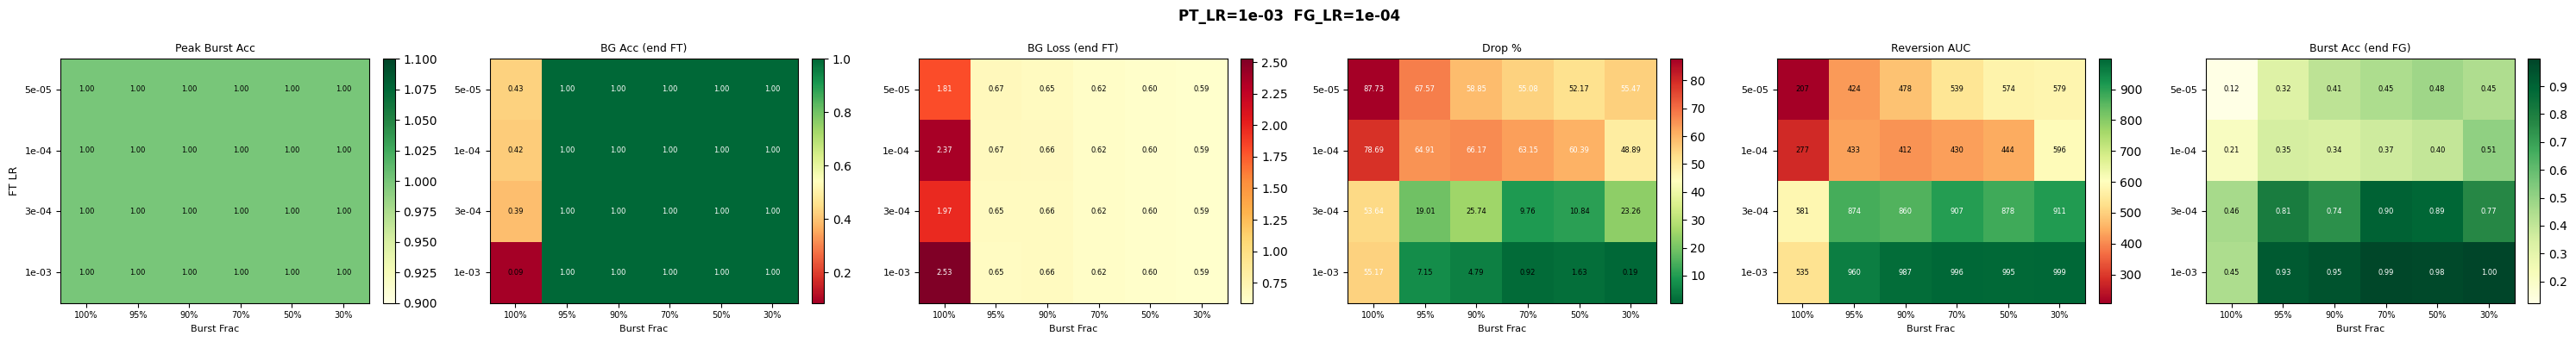

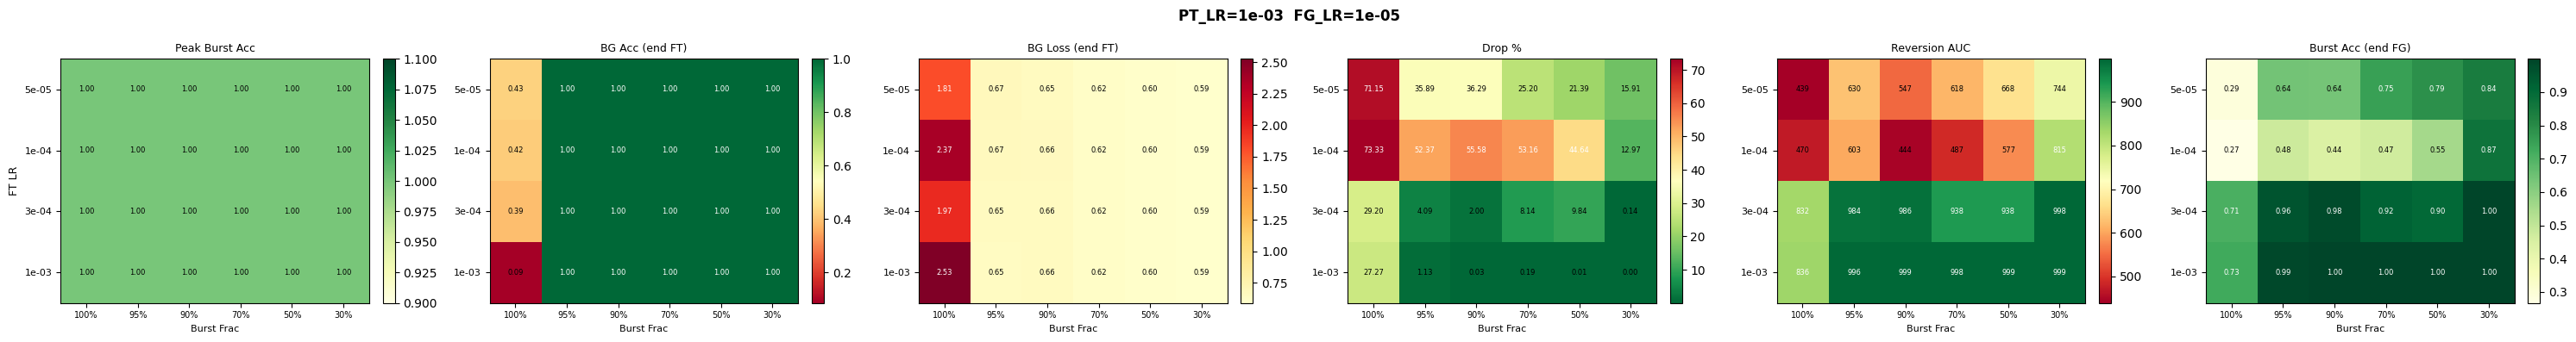

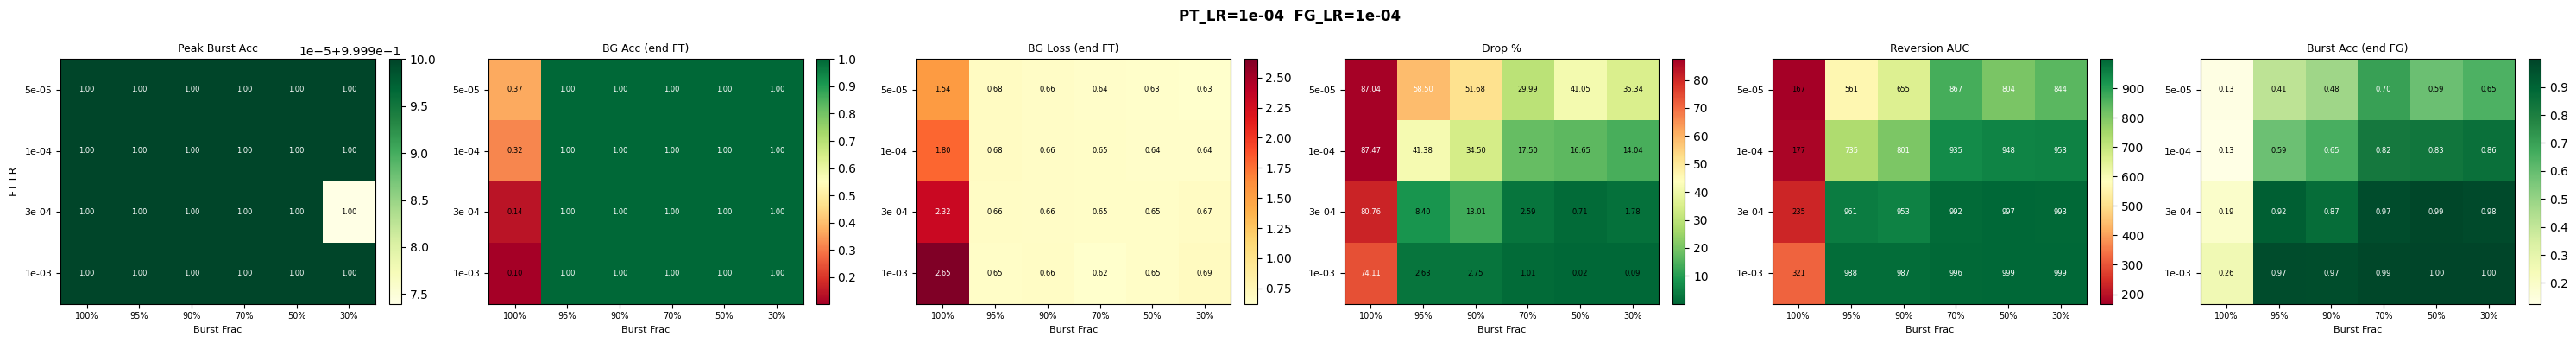

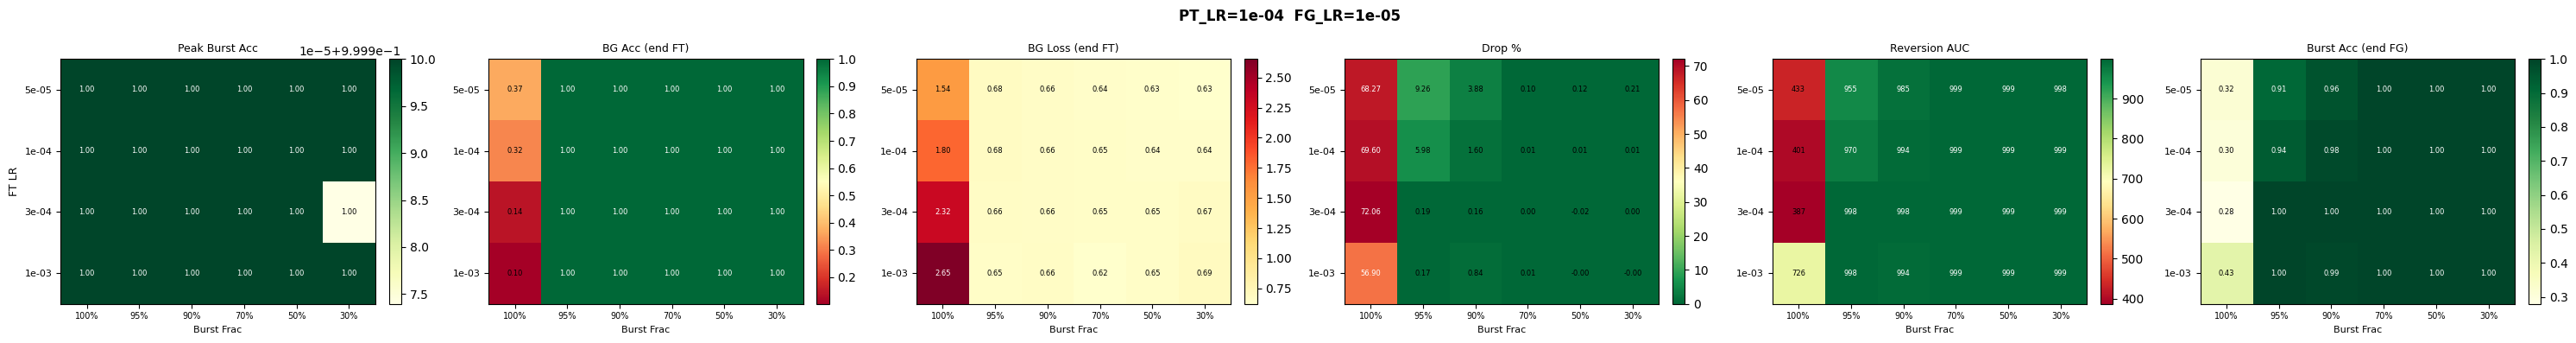

In [15]:
# ── Heatmaps: one row of 6 heatmaps per (PT_LR, FG_LR) ──
lr_labels = [f"{lr:.0e}" for lr in LRS]
frac_labels = [f"{int(f*100)}%" for f in FRACS]

for (pt_lr, fg_lr), res in all_results.items():
    ft_results = res["ft_results"]
    fg_results = res["fg_results"]

    g_peak   = np.zeros((n_ft_lr, n_frac))
    g_drop   = np.zeros((n_ft_lr, n_frac))
    g_auc    = np.zeros((n_ft_lr, n_frac))
    g_bg_acc = np.zeros((n_ft_lr, n_frac))
    g_bg_loss= np.zeros((n_ft_lr, n_frac))
    g_fg_burst= np.zeros((n_ft_lr, n_frac))

    for idx, (ft_r, fg_r) in enumerate(zip(ft_results, fg_results)):
        i_lr, i_fr = idx // n_frac, idx % n_frac
        g_peak[i_lr, i_fr]    = ft_r["peak_burst"]
        g_drop[i_lr, i_fr]    = fg_r["dropoff_pct"]
        g_auc[i_lr, i_fr]     = fg_r["reversion_auc"]
        g_bg_acc[i_lr, i_fr]  = ft_r["log"]["acc_other"][-1]
        g_bg_loss[i_lr, i_fr] = ft_r["log"]["loss_other"][-1]
        g_fg_burst[i_lr, i_fr]= fg_r["log"]["acc_burst"][-1]

    grids = [
        ("Peak Burst Acc", g_peak, "YlGn"),
        ("BG Acc (end FT)", g_bg_acc, "RdYlGn"),
        ("BG Loss (end FT)", g_bg_loss, "YlOrRd"),
        ("Drop %", g_drop, "RdYlGn_r"),
        ("Reversion AUC", g_auc, "RdYlGn"),
        ("Burst Acc (end FG)", g_fg_burst, "YlGn"),
    ]

    fig, axes = plt.subplots(1, 6, figsize=(30, 4))
    for idx, (title, grid, cmap) in enumerate(grids):
        ax = axes[idx]
        im = ax.imshow(grid, aspect="auto", cmap=cmap)
        ax.set_xticks(range(n_frac)); ax.set_xticklabels(frac_labels, fontsize=7)
        ax.set_yticks(range(n_ft_lr)); ax.set_yticklabels(lr_labels, fontsize=8)
        ax.set_xlabel("Burst Frac", fontsize=8)
        if idx == 0:
            ax.set_ylabel("FT LR", fontsize=9)
        ax.set_title(title, fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        for i in range(n_ft_lr):
            for j in range(n_frac):
                val = grid[i, j]
                txt = f"{val:.2f}" if abs(val) < 100 else f"{val:.0f}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=6,
                        color="white" if abs(val - grid.min()) > 0.6 * (grid.max() - grid.min()) else "black")

    fig.suptitle(f"PT_LR={pt_lr:.0e}  FG_LR={fg_lr:.0e}",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()

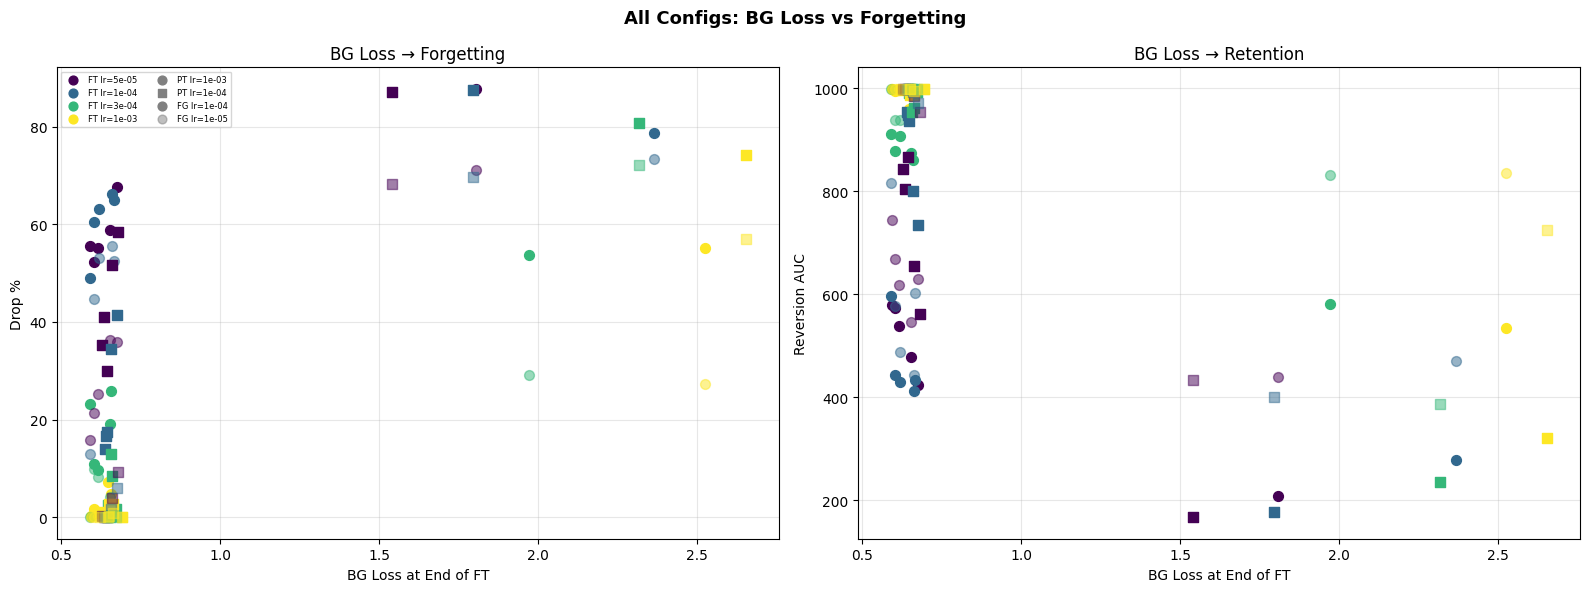

In [16]:
# ── Scatter: BG loss at end of FT vs forgetting (all combos on one plot) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

pt_markers = {PT_LRS[0]: "o", PT_LRS[1]: "s"}
fg_alphas = {FG_LRS[0]: 1.0, FG_LRS[1]: 0.5}

for (pt_lr, fg_lr), res in all_results.items():
    ft_results = res["ft_results"]
    fg_results = res["fg_results"]
    marker = pt_markers[pt_lr]
    alpha = fg_alphas[fg_lr]

    for idx, (ft_r, fg_r) in enumerate(zip(ft_results, fg_results)):
        i_lr = idx // n_frac
        frac = ft_r["burst_frac"]
        color = plt.cm.viridis(i_lr / max(n_ft_lr - 1, 1))
        bg_loss = ft_r["log"]["loss_other"][-1]

        ax1.scatter(bg_loss, fg_r["dropoff_pct"], c=[color], marker=marker,
                    s=50, zorder=3, alpha=alpha)
        ax2.scatter(bg_loss, fg_r["reversion_auc"], c=[color], marker=marker,
                    s=50, zorder=3, alpha=alpha)

# Legends
for i, lr in enumerate(LRS):
    color = plt.cm.viridis(i / max(n_ft_lr - 1, 1))
    ax1.scatter([], [], c=[color], label=f"FT lr={lr:.0e}", s=40)
for pt_lr, m in pt_markers.items():
    ax1.scatter([], [], c="gray", marker=m, label=f"PT lr={pt_lr:.0e}", s=40)
for fg_lr, a in fg_alphas.items():
    ax1.scatter([], [], c="gray", alpha=a, label=f"FG lr={fg_lr:.0e}", s=40)

ax1.set_xlabel("BG Loss at End of FT"); ax1.set_ylabel("Drop %")
ax1.set_title("BG Loss → Forgetting"); ax1.legend(fontsize=6, ncol=2); ax1.grid(True, alpha=0.3)
ax2.set_xlabel("BG Loss at End of FT"); ax2.set_ylabel("Reversion AUC")
ax2.set_title("BG Loss → Retention"); ax2.grid(True, alpha=0.3)
fig.suptitle("All Configs: BG Loss vs Forgetting", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()